# Simulate determinsitic model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import erf
#plt.style.use("ggplot")

The cell population dynamics are
\begin{align}
    \begin{split}
       \text{antigen:}~~~ \frac{d a_1}{dt}&= a_1g_{a_1}\left(1-\frac{t}{T_{a_1}}\right)-a_1Ed_{a_1},\\
        \text{naive:}~~~\frac{d N}{dt} &= -P_1 N(g_{N,M} + g_{N,E}) p_A,\\
    \text{effector:}~~~\frac{d E}{dt} &= P_1 Ng_{N,E} p_A + Mg_{M,E} + E\left(g_E -g_{E,M}-
        d_{E}\right) ,\\
    \text{memory:}~~~\frac{d M}{dt} &= P_1 N g_{N,M} p_A + E g_{E,M}-Mg_{M,E}, \\ %T\left( g_{T} -d_{T}(c_1)\right),
    \end{split}
\end{align}
where
\begin{align*}
    \text{pMHC complex:}~~~P_1(a_1;c_2) &=\frac{(g_{0,P_1} + g_{1,P_1}c_2)}{d_{P_1}}a_1(t) + \Gamma_{P_1}(t),\\
    \text{activation:}~~~p_A(t_1) &= \frac{1}{2}\left(1+\text{erf}\left(\frac{\log[t_1^2]-\mu _\Theta}{\sqrt{2} \sigma_\Theta}\right)\right),\\
    g_E(c_1) &=\tilde g_{E}\frac{c_1^2}{k_{E}^2 + c_1^2},\\
    g_{N,X}(c_1) &= \text{ constant,} \\ %g_{N,A,max}\frac{1}{k_{N}+ P_1 + N},\\
    g_{E,M}(c_1) &=\tilde g_{E,M}\frac{k_{E,M}^2}{k_{E,M}^2 + c_1^2},\\
    g_{M,E}(c_1) &=\tilde g_{M,E}\frac{c_1^2}{k_{M,E}^2 + c_1^2},\\
    %d_{X}(P_1;c_i) &=\tau_X^{-1}\frac{k_{X}^2}{k_{X}^2 + c_1^2},\\
\end{align*}
with antigen binding time $t_1$, and activation threshold $\Theta \sim \mathcal{N}(\mu_\Theta;\sigma_\Theta^2)$. The cytokine dynamics are
\begin{align}
    \frac{d c_1}{dt} &= I_{c_1}+Eg_{c_1} -c_1\left(T f_T + d_{c_1}\right),\\
    \frac{d c_2}{dt} &=
    E g_{c_2}-c_2 d_{c_2},
\end{align}
where
\begin{align*}
    g_{c_i}(P_1)&=\tilde g_{c_i}\frac{P_1}{k_{c_i}+ P_1}.
\end{align*}


## (1) Run test simulations

In [53]:
# Define simulation parameters
duration = 10
steps = 10**4 # grid size for numerical odes
ts = np.linspace(0, duration, steps + 1)

# antigens
g_a1 = 2.4
d_a1 = 0.0072 # proxy for virulence
a1_0 = 10000
T_a1 = 10

P2 = 2000
g0_P1 = 0.01
g1_P1 = 0.001
tau_P1 = 0.1
#f_E_P1 = 24*np.log(2)/3.5 # consumption from engagement with TCR
t1, t2 = 10, 2 # dissociation time
n, m = 4, 2

# cells
N0 = 1000
Treg0 = 1000 # Tregs
g_NE_max = 0.0036
g_NM_max = 0.012
g_E_max = 4.0
g_ME_max = 4.0
g_EM_max = 0.036
g_T_max = 4
k_E = 10**(-12)*(6.0221408*10**23)*50*10**(-6)
k_M = k_E
tau_E, tau_T = 3, 3

# cytokines
g_c1, g_c2 = 1000*3600*24, 100#*3600*24
f_T = 0*3600*24
k_c1, k_c2_a = 10, 10
tau_c = 3/24
I_c1, I_c2 = 0, 0

# set initial state
init_state = np.array([a1_0, N0, 0, 0, Treg0]) #a1, N, E, M, T

# activation threshold
mu_theta = np.log(t2**2)
sigma_theta = mu_theta

In [59]:
# Define functions for simulations
def hl_u(x,k):
    return (x**1)/(k**1 + x**1)

def c2_ss(a1, E):
    
    return E*g_c2*tau_c

def P1(a1,E):
    
    mu = (g0_P1 + g1_P1*c2_ss(a1, E))*a1*tau_P1
    Gamma = np.random.normal(loc = mu, scale = np.sqrt(np.maximum(0,2*mu/tau_P1)))

    return mu, np.maximum(0, Gamma)

def c1_ss(a1, E, T):
    
    P = P1(a1,E)[1]
    
    return (E*g_c1*P/(k_c1 + P) + I_c1)/(T*f_T + 1/tau_c)

def p_A(t1, E):
    
    return (1 + erf((np.log(t1**2)-mu_theta)/np.sqrt(2*sigma_theta**2)))/2

def g_NE(a1,N,E):
    
    P = P1(a1,E)[1]
    return g_NE_max

def g_NM(a1,N,E):
    
    P = P1(a1,E)[1]
    return g_NM_max

def g_E(a1, E, T):
    
    return g_E_max*hl_u(c1_ss(a1,E,T), k_E)

def g_T(a1, E, T):
    
    return g_T_max #*hl_u(c1_ss(a1,E,T), k_T)

def g_ME(a1,E,T):
    
    return g_ME_max*(hl_u(c1_ss(a1, E, T),k_M))

def g_EM(a1,E,T):
    
    return g_EM_max*(1-hl_u(c1_ss(a1, E, T),k_E))

def d_E(a1,E,T):
    
    return 1/tau_E

def d_T(a1,E,T):
    
    return 0#(1-hl_u(c1_ss(a1,E,T),k_T))/tau_T

In [64]:
P1(np.ones(5),1000)

(array([1.251, 1.251, 1.251, 1.251, 1.251]),
 array([5.02344413, 5.02344413, 5.02344413, 5.02344413, 5.02344413]))

In [60]:
# define dynamics
def state_dyn(t, z):
    
    a1, N, E, M, T = z
    return [a1*g_a1*(1- t/T_a1) - d_a1*a1*E,\
            -(g_NE(a1,N,E)+g_NM(a1,N,E))*N*p_A(t1,E)*P1(a1,E)[1],\
            g_NE(a1,N,E)*N*p_A(t1,E)*P1(a1,E)[1] + M*g_ME(a1,E,T) +  E*(g_E(a1,E,T) - g_EM(a1,E,T) - d_E(a1,E,T)), \
            g_NM(a1,N,E)*N*p_A(t1,E)*P1(a1,E)[1] + E*g_EM(a1,E,T) - M*g_ME(a1,E,T), \
            0*T*(g_T(a1, E, T) - d_T(a1,E,T))]

In [61]:
# compute state and costate dynamics
states = solve_ivp(state_dyn, [0, duration], init_state,
                dense_output=True).sol(ts).T

a1, N, E, M, T = states[:,0], states[:,1], states[:,2], states[:,3], states[:,4]

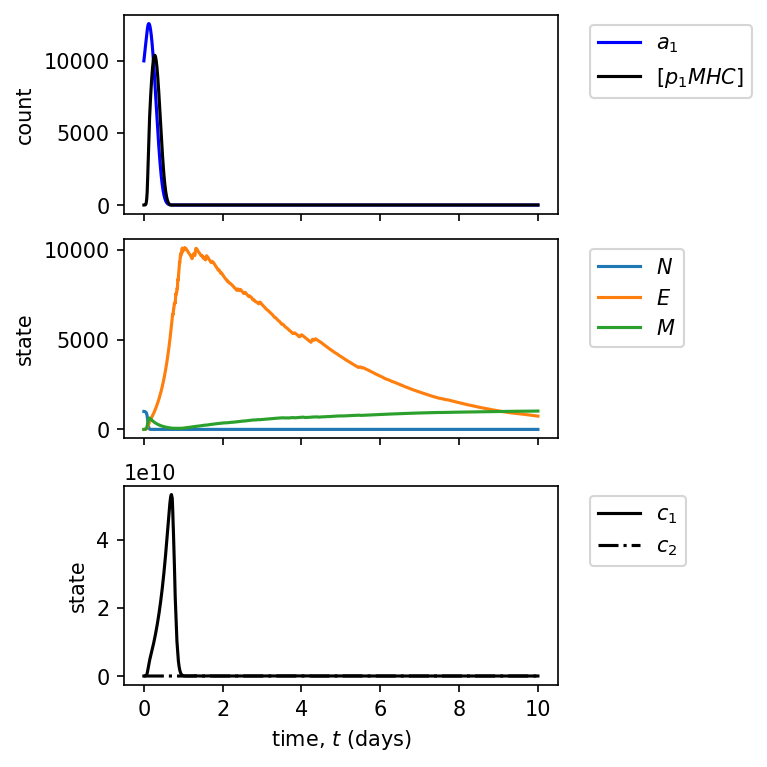

In [62]:
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True,figsize=(5,5))
#fig.suptitle(r'Antigen-CD8+ cell dynamics during an acute infection')
ax1.plot(ts, a1, 'b', label = r'$a_1$')
ax1.plot(ts, P1(a1, E)[1], 'k', label = r'$[p_1MHC]$')
ax1.set(ylabel='count')
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, M, label = r'$M$')
#ax2.plot(ts, E+M, label = r'$E+M$')
#ax2.plot(ts, T, label = r'$T$')
ax2.set(ylabel='state')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax3.plot(ts, c1_ss(a1, E, T),'k-', label = r'$c_1$')
ax3.plot(ts, c2_ss(a1,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='state')
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig('virus-effector dynamics.png', dpi=150)

0.9898815961341647


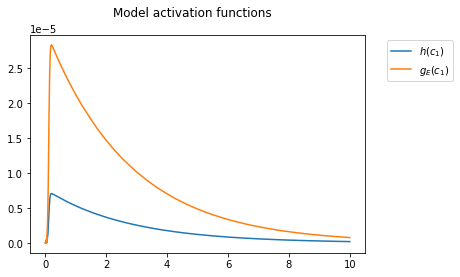

In [52]:
plt.figure(2)
plt.suptitle(r'Model activation functions')
#plt.plot(ts,p_A(t1,E), label = r'$p_A$')
plt.plot(ts, hl_u(c1_ss(a1,E,T),k_E), label = r'$h(c_1)$')
plt.plot(ts,g_E(a1,E,T), label = r'$g_E(c_1)$')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
print(p_A(t1,E))

### Relationship between antigen and immune response

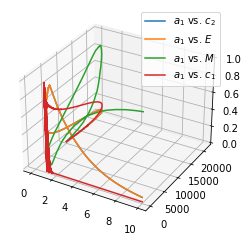

In [8]:
ax = plt.axes(projection='3d')
ax.plot3D(ts, a1, c2_ss(a1,E)/np.max(c2_ss(a1,E)), label = r'$a_1$ vs. $c_2$')
ax.plot3D(ts, a1, E/np.max(E),label = r'$a_1$ vs. $E$')
ax.plot3D(ts, a1, M/np.max(M),label = r'$a_1$ vs. $M$')
ax.plot3D(ts, a1, c1_ss(a1,E,T)/np.max(c1_ss(a1, E, T)),label = r'$a_1$ vs. $c_1$')
ax.legend()

### Response statistics

In [9]:
# Fraction of memory of effector peak
print('Long-term memory represents a fraction of maximal response:', M[-1]/np.max(E))
a1[np.argmax(E)]
P1(a1,E)
np.max(E)

Long-term memory represents a fraction of maximal response: 0.09866192593248217


4920.212159317622

### Sandbox

In [10]:
(c1_ss(N, E, T, a1)/(N+E+T))[-1]
a1[-1]
pmhc1(a1, E)[-1]

TypeError: c1_ss() takes 3 positional arguments but 4 were given

In [ ]:
E_ss = (g_E_max*tau_E*g_c1 - k_E_c1*T*(f_E + f_T)*(1 + tau_E*g_EM_max)\
 -np.sqrt(-4*f_E*(k_E_c1**2)*(T**2)*f_T*((1 + tau_E*g_EM_max)**2)\
          +(f_E*k_E_c1*T - g_E_max*tau_E*g_c1 + k_E_c1*T*(f_T + tau_E*(f_E+f_T)*g_EM_max))**2))/(2*f_E*k_E_c1*(1 + tau_E*g_EM_max))
E_ss_approx = (g_E_max*tau_E*g_c1 - k_E_c1*T*(f_E + f_T)*(1 + tau_E*g_EM_max))/(f_E*k_E_c1*(1 + tau_E*g_EM_max))
plt.figure(5)
plt.plot(ts, E_ss,label = r'$E_{ss}$')
plt.plot(ts, E_ss_approx,label = r'$E_{ss,approx}$')
plt.plot(ts, E, label = r'$E$')
plt.legend()

In [ ]:
print(np.max(E),E_ss[np.argmax(E)])

In [ ]:
(g_E_max*tau_E*g_c1-k_E_c1*T*(f_E + f_T)*(1 + tau_E*g_EM_max))/(f_E*k_E_c1*(1 + tau_E*g_EM_max))